In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_int = pd.read_csv('vector_sum_results_int.csv')
df_float = pd.read_csv('vector_sum_results_float.csv')
df_double = pd.read_csv('vector_sum_results_double.csv')

Расчет ускорения ядра

In [3]:
df_int['Speedup_kernel'] = df_int['CPU_Time_ms'] / df_int['GPU_Kernel_ms']
df_float['Speedup_kernel'] = df_float['CPU_Time_ms'] / df_float['GPU_Kernel_ms']
df_double['Speedup_kernel'] = df_double['CPU_Time_ms'] / df_double['GPU_Kernel_ms']

График времени выполнения

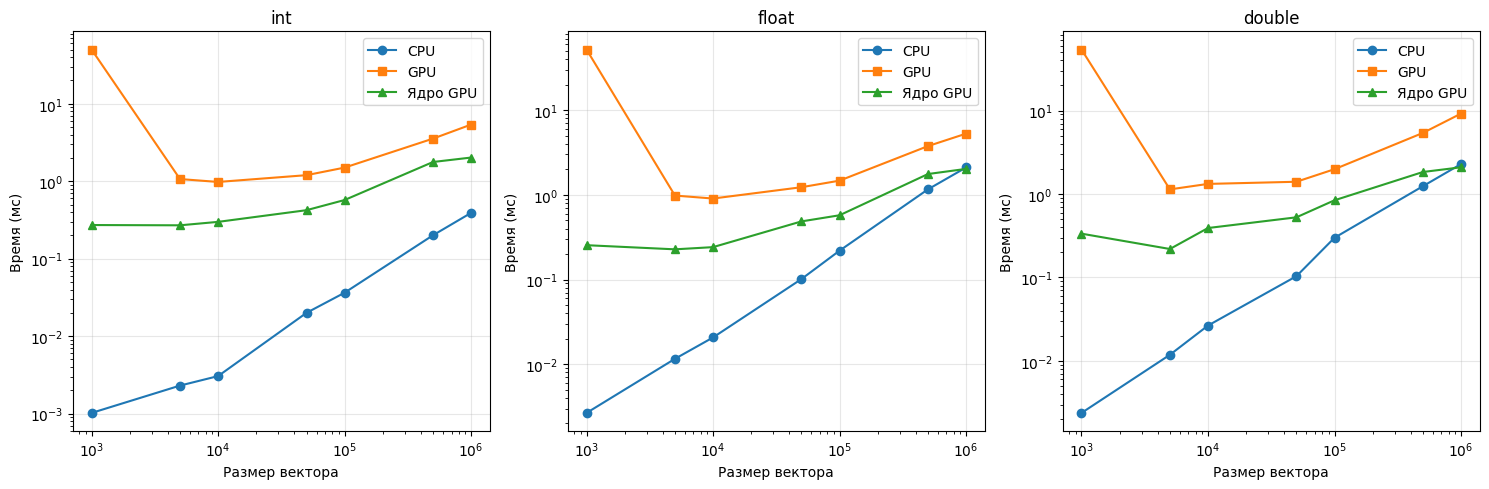

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(df_int['Size'], df_int['CPU_Time_ms'], 'o-', label='CPU')
axes[0].plot(df_int['Size'], df_int['GPU_Time_ms'], 's-', label='GPU')
axes[0].plot(df_int['Size'], df_int['GPU_Kernel_ms'], '^-', label='Ядро GPU')
axes[0].set_xlabel('Размер вектора')
axes[0].set_ylabel('Время (мс)')
axes[0].set_title('int')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_float['Size'], df_float['CPU_Time_ms'], 'o-', label='CPU')
axes[1].plot(df_float['Size'], df_float['GPU_Time_ms'], 's-', label='GPU')
axes[1].plot(df_float['Size'], df_float['GPU_Kernel_ms'], '^-', label='Ядро GPU')
axes[1].set_xlabel('Размер вектора')
axes[1].set_ylabel('Время (мс)')
axes[1].set_title('float')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_double['Size'], df_double['CPU_Time_ms'], 'o-', label='CPU')
axes[2].plot(df_double['Size'], df_double['GPU_Time_ms'], 's-', label='GPU')
axes[2].plot(df_double['Size'], df_double['GPU_Kernel_ms'], '^-', label='Ядро GPU')
axes[2].set_xlabel('Размер вектора')
axes[2].set_ylabel('Время (мс)')
axes[2].set_title('double')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_comparison.png', dpi=150)
plt.show()

График ускорения

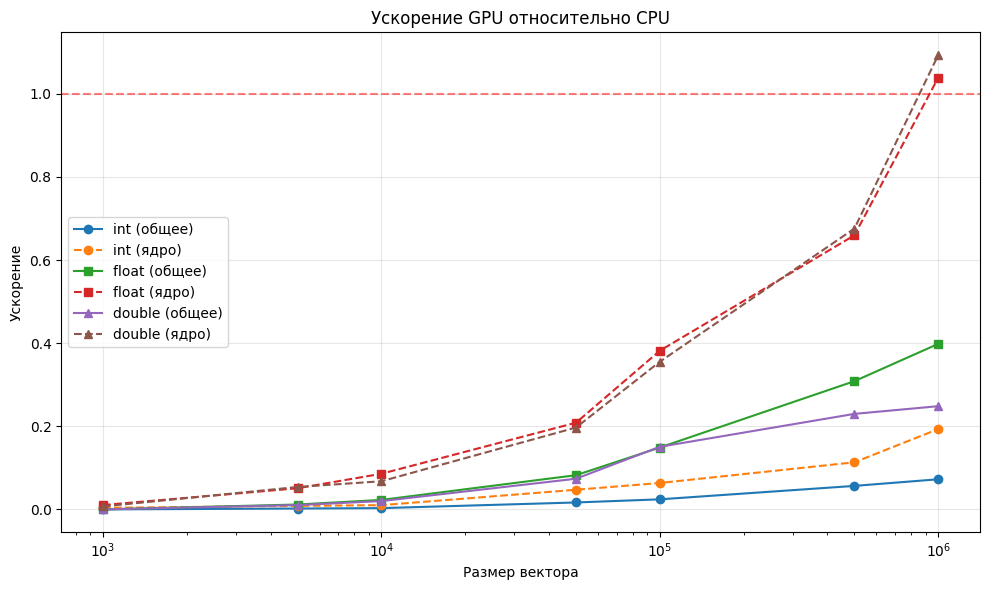

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(df_int['Size'], df_int['Speedup'], 'o-', label='int (общее)')
plt.plot(df_int['Size'], df_int['Speedup_kernel'], 'o--', label='int (ядро)')
plt.plot(df_float['Size'], df_float['Speedup'], 's-', label='float (общее)')
plt.plot(df_float['Size'], df_float['Speedup_kernel'], 's--', label='float (ядро)')
plt.plot(df_double['Size'], df_double['Speedup'], '^-', label='double (общее)')
plt.plot(df_double['Size'], df_double['Speedup_kernel'], '^--', label='double (ядро)')

plt.xlabel('Размер вектора')
plt.ylabel('Ускорение')
plt.title('Ускорение GPU относительно CPU')
plt.xscale('log')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('speedup.png', dpi=150)
plt.show()

Сравнение CPU времени

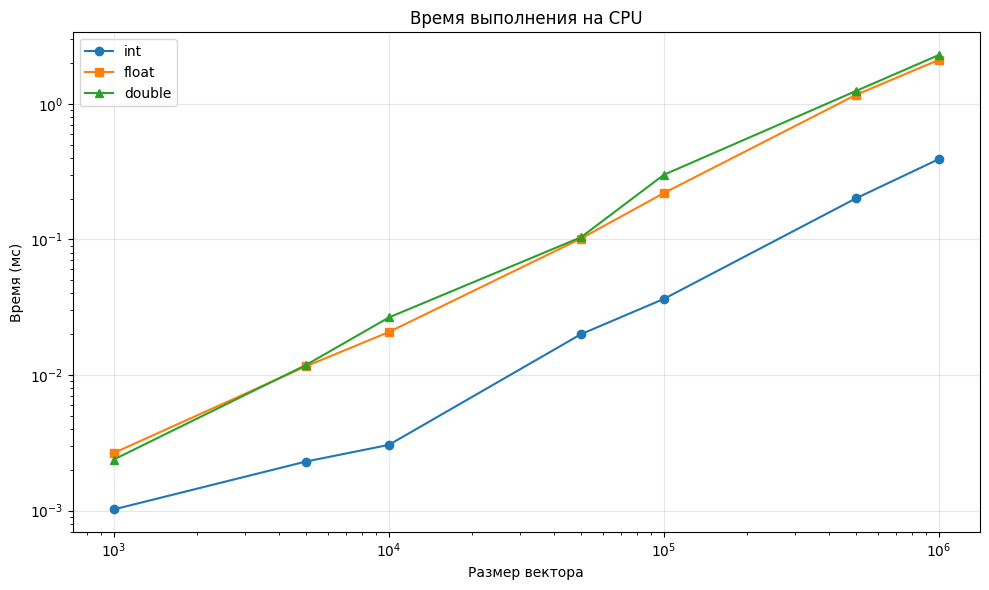

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(df_int['Size'], df_int['CPU_Time_ms'], 'o-', label='int')
plt.plot(df_float['Size'], df_float['CPU_Time_ms'], 's-', label='float')
plt.plot(df_double['Size'], df_double['CPU_Time_ms'], '^-', label='double')

plt.xlabel('Размер вектора')
plt.ylabel('Время (мс)')
plt.title('Время выполнения на CPU')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cpu_time.png', dpi=150)
plt.show()

Сравнение GPU времени

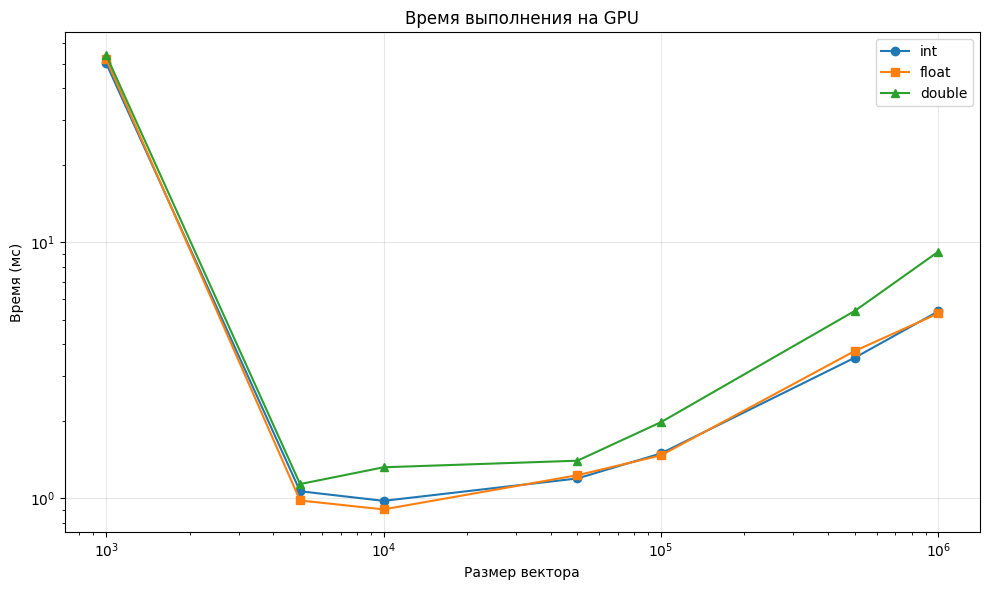

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(df_int['Size'], df_int['GPU_Time_ms'], 'o-', label='int')
plt.plot(df_float['Size'], df_float['GPU_Time_ms'], 's-', label='float')
plt.plot(df_double['Size'], df_double['GPU_Time_ms'], '^-', label='double')

plt.xlabel('Размер вектора')
plt.ylabel('Время (мс)')
plt.title('Время выполнения на GPU')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gpu_time.png', dpi=150)
plt.show()

Таблица результатов

In [8]:
print("Результаты для int:")
print(df_int[['Size', 'CPU_Time_ms', 'GPU_Time_ms', 'GPU_Kernel_ms', 'Speedup', 'Speedup_kernel']].to_string(index=False))

print("\nРезультаты для float:")
print(df_float[['Size', 'CPU_Time_ms', 'GPU_Time_ms', 'GPU_Kernel_ms', 'Speedup', 'Speedup_kernel']].to_string(index=False))

print("\nРезультаты для double:")
print(df_double[['Size', 'CPU_Time_ms', 'GPU_Time_ms', 'GPU_Kernel_ms', 'Speedup', 'Speedup_kernel']].to_string(index=False))

Результаты для int:
   Size  CPU_Time_ms  GPU_Time_ms  GPU_Kernel_ms  Speedup  Speedup_kernel
   1000      0.00102     50.13420        0.27181 0.000020        0.003753
   5000      0.00230      1.06639        0.26965 0.002157        0.008530
  10000      0.00305      0.97814        0.29866 0.003118        0.010212
  50000      0.01999      1.19678        0.42270 0.016703        0.047291
 100000      0.03636      1.49889        0.57176 0.024258        0.063593
 500000      0.20070      3.54701        1.77073 0.056583        0.113343
1000000      0.39042      5.38401        2.02028 0.072515        0.193250

Результаты для float:
   Size  CPU_Time_ms  GPU_Time_ms  GPU_Kernel_ms  Speedup  Speedup_kernel
   1000      0.00266     52.09460        0.25466 0.000051        0.010445
   5000      0.01159      0.98143        0.22754 0.011809        0.050936
  10000      0.02072      0.90567        0.24153 0.022878        0.085786
  50000      0.10145      1.23200        0.48629 0.082346        0.20

Сводная таблица ускорений

In [9]:
summary = pd.DataFrame({
    'Размер': df_int['Size'],
    'int (общее)': df_int['Speedup'],
    'int (ядро)': df_int['Speedup_kernel'],
    'float (общее)': df_float['Speedup'],
    'float (ядро)': df_float['Speedup_kernel'],
    'double (общее)': df_double['Speedup'],
    'double (ядро)': df_double['Speedup_kernel']
})
print("\nСводная таблица ускорений:")
print(summary.to_string(index=False))

summary.to_csv('speedup_summary.csv', index=False)


Сводная таблица ускорений:
 Размер  int (общее)  int (ядро)  float (общее)  float (ядро)  double (общее)  double (ядро)
   1000     0.000020    0.003753       0.000051      0.010445        0.000044       0.007100
   5000     0.002157    0.008530       0.011809      0.050936        0.010417       0.053984
  10000     0.003118    0.010212       0.022878      0.085786        0.020061       0.067780
  50000     0.016703    0.047291       0.082346      0.208620        0.073842       0.196979
 100000     0.024258    0.063593       0.148938      0.381825        0.150694       0.355376
 500000     0.056583    0.113343       0.308548      0.659540        0.229871       0.675778
1000000     0.072515    0.193250       0.398327      1.038795        0.248369       1.093186
